Instructions
Objective:
To build a time sequence model for predicting short term future stock prices from historical data.

Data:
Historical stock price data on US-based stocks, last updated in 2017. The dataset is available at Huge Stock Market Dataset | Kaggle and is provided by Boris Marjanovic. A list of stock ticker symbols is available at List of All Stock Ticker Symbols - Stock Analysis, to help identify the name of the stock from the txt file name.

Problem Statement:
An investment company is interested in learning about the potential profit in frequent buy/sell stock transactions. You are tasked with developing a time sequence model to predict the price two days ahead based on recent prices. Choose four (or more) of the data files for training and a separate two for validation. Once the model is finalized, demonstrate how well your model makes predictions by using two other data files for testing.

Steps to be completed:
Create a Jupyter notebook and complete the following steps:


In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, Conv1D, Dropout, MaxPooling1D, SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

### Data
A) Select four (or more) of the data files in stocks.zip to use as training data, two others for validation, and two others for testing.

In [2]:
training_csv = ['amn.us.csv', 'bspm.us.csv', 'hqcl.us.csv', 'ifn.us.csv']
val_csv    = ['jhme.us.csv', 'vno_l.us.csv']
test_csv = ['vmo.us.csv', 'ziop.us.csv']

# Initialize combined DataFrames
training_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])
val_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])
test_df = pd.DataFrame(columns=['Date','Open','High','Low','Close','Volume','OpenInt'])

# Dictionary for individual stock DataFrames
dfs = {}

# TRAINING
for i in training_csv:
    url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/{i}"
    df = pd.read_csv(url)
    training_df = pd.concat([training_df, df], ignore_index=True)
    dfs[i] = df.copy()

# VALIDATION  
for i in val_csv:
    url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/{i}"
    df = pd.read_csv(url)
    val_df = pd.concat([val_df, df], ignore_index=True)
    dfs[i] = df.copy()

# TEST
for i in test_csv:
    url = f"https://raw.githubusercontent.com/Hunteracademic/Neural_network_group_7/master/stocks_folder/Stocks/Testing/{i}"
    df = pd.read_csv(url)
    test_df = pd.concat([test_df, df], ignore_index=True)
    dfs[i] = df.copy()

In [3]:
training_df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,13.2,13.38,13.03,13.28,28800,0
1,2005-02-28,13.38,13.53,13.32,13.53,104100,0
2,2005-03-01,13.49,13.49,13.08,13.17,249100,0
3,2005-03-02,13.18,13.43,13.18,13.36,62700,0
4,2005-03-03,13.4,13.72,13.3,13.57,110700,0


In [4]:
dfs

{'amn.us.csv':             Date   Open   High     Low  Close  Volume  OpenInt
 0     2005-02-25  13.20  13.38  13.030  13.28   28800        0
 1     2005-02-28  13.38  13.53  13.320  13.53  104100        0
 2     2005-03-01  13.49  13.49  13.080  13.17  249100        0
 3     2005-03-02  13.18  13.43  13.180  13.36   62700        0
 4     2005-03-03  13.40  13.72  13.300  13.57  110700        0
 ...          ...    ...    ...     ...    ...     ...      ...
 3196  2017-11-06  40.80  42.65  40.550  42.50  777366        0
 3197  2017-11-07  42.85  43.75  41.550  41.95  463441        0
 3198  2017-11-08  42.00  43.25  41.750  43.15  530437        0
 3199  2017-11-09  42.70  43.20  42.400  43.05  360368        0
 3200  2017-11-10  43.05  43.95  42.875  43.85  397824        0
 
 [3201 rows x 7 columns],
 'bspm.us.csv':             Date     Open   High    Low    Close  Volume  OpenInt
 0     2008-12-18  36.7500  57.75  36.75  36.7500      29        0
 1     2009-01-06  21.2100  21.21  21.21 

B) Plot the closing price in each data file using dates to label the x-axis.

amn.us.csv: (3201, 7) rows


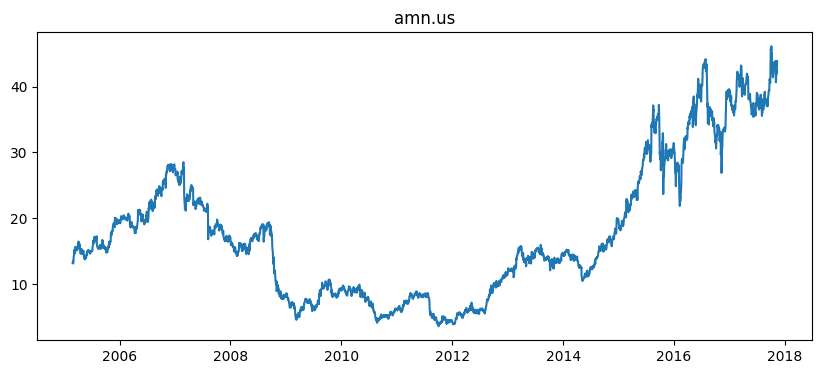

bspm.us.csv: (2106, 7) rows


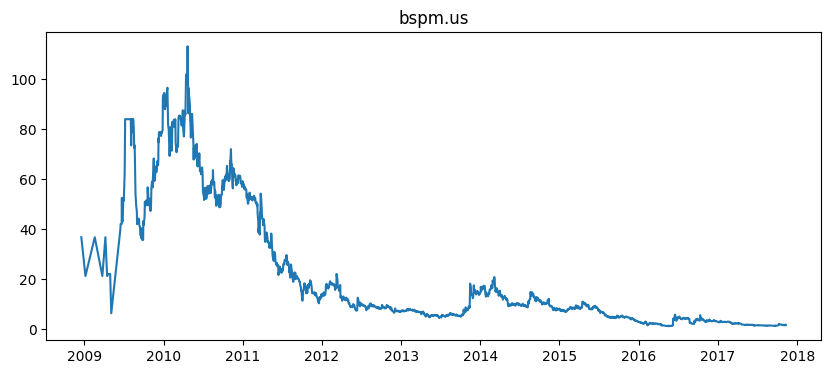

hqcl.us.csv: (2744, 7) rows


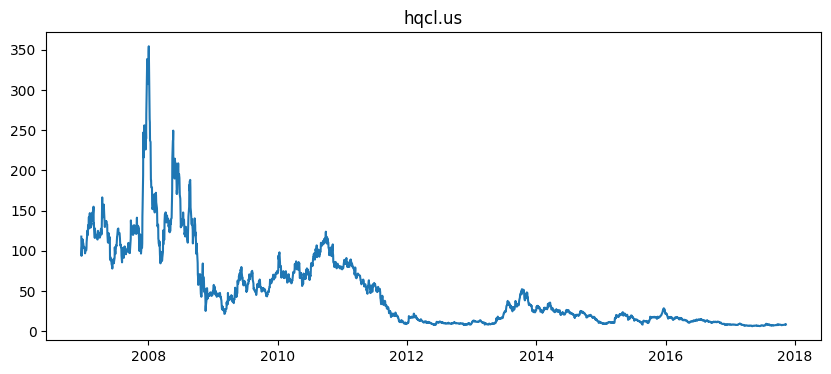

ifn.us.csv: (3201, 7) rows


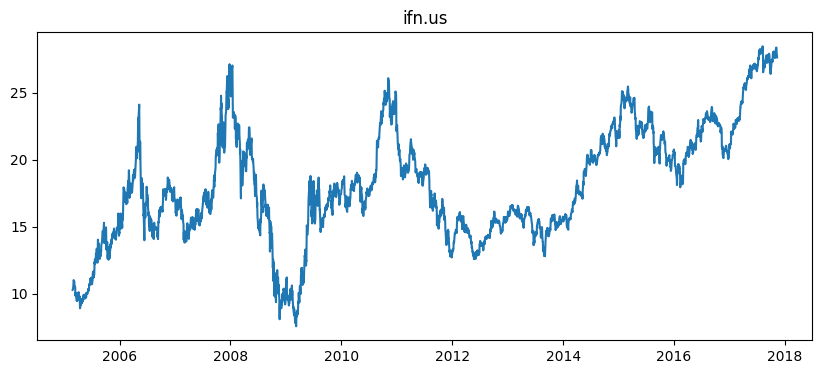

jhme.us.csv: (257, 7) rows


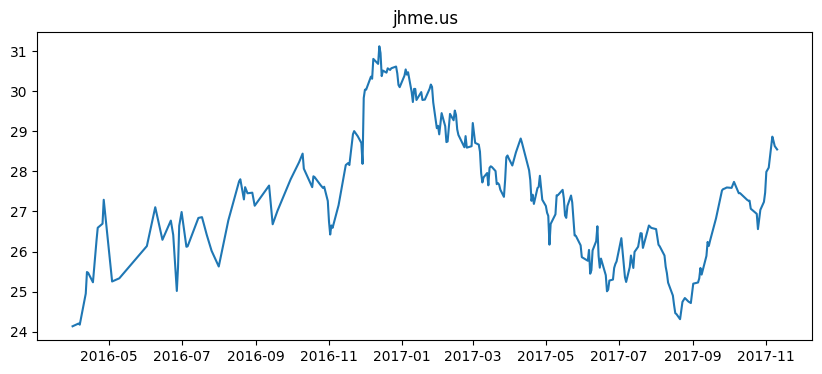

vno_l.us.csv: (1203, 7) rows


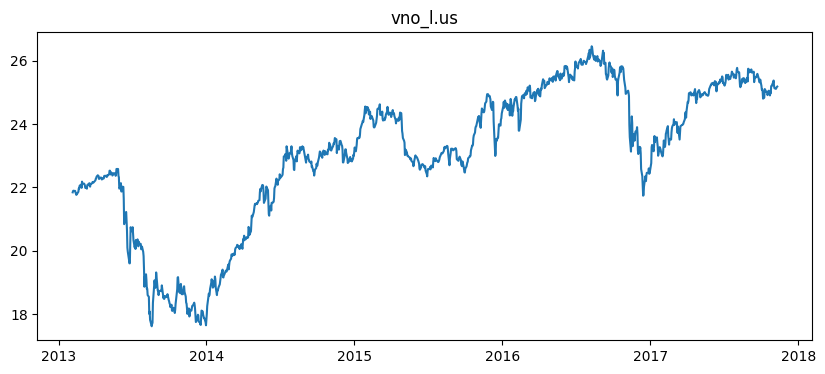

vmo.us.csv: (3201, 7) rows


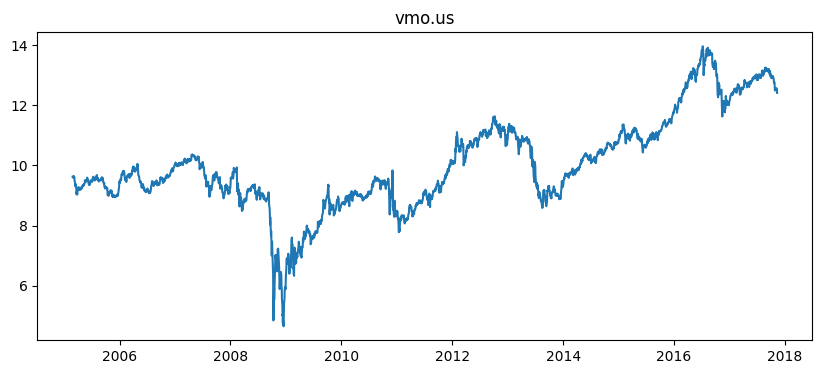

ziop.us.csv: (2966, 7) rows


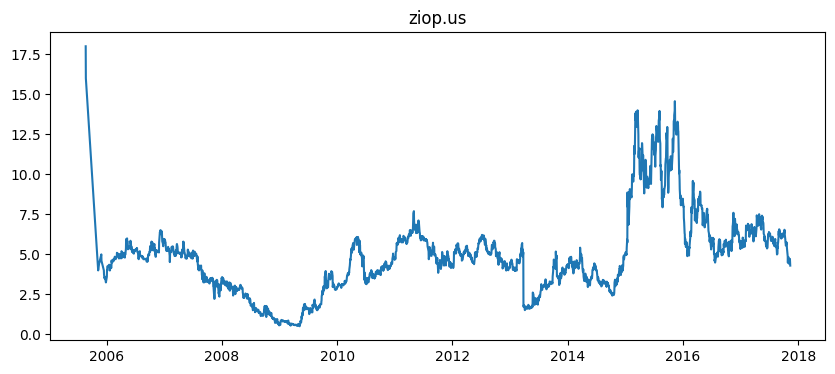

In [5]:
# loop through dfs dictionary of dataframes
for filename, df in dfs.items():
    df['Date'] = pd.to_datetime(df['Date'])
    print(f"{filename}: {df.shape} rows")
    
    plt.figure(figsize=(10, 4))
    plt.plot(df['Date'], df['Close'])
    plt.title(filename[:-4])
    plt.show()

C) Create a function that loads the closing prices from a data file into input and label numpy arrays that are appropriate for training time sequence models to predict a price two days into the future, using a lookback value of your choice.

In [6]:
def create_sequences(df, lookback=10, future_days=2):
    """
    Convert closing prices to input/label arrays for time series prediction.
    
    Args:
        df: DataFrame with 'Date' and 'Close' columns
        lookback: number of past days to use as input
        future_days: days into future to predict
    
    Returns:
        X: input sequences (n_samples, lookback, 1)
        y: target prices (n_samples,)
    """
    prices = df.sort_values('Date')['Close'].values
    
    X, y = [], []
    
    for i in range(lookback, len(prices) - future_days):
        # Input: past lookback days
        X.append(prices[i-lookback:i])
        # Target: price future_days ahead
        y.append(prices[i + future_days])
    
    return np.array(X), np.array(y)

D) Use the function created in the previous step to load all of the data files into 2d numpy arrays. Concatenate the input arrays and the label arrays. After this step, you should have a single array of sequences for inputs, and a single array of labels.

In [7]:
look_back = 10
future_days = 2

all_X, all_y = [], []

for filename, df in dfs.items():
    print(f"Processing {filename}")
    
    df['Date'] = pd.to_datetime(df['Date'])
    X_stock, y_stock = create_sequences(df, lookback=look_back, future_days=future_days)
    
    print(f"{X_stock.shape[0]} sequences created")
    all_X.append(X_stock)
    all_y.append(y_stock)

X_all = np.vstack(all_X)
y_all = np.hstack(all_y)

print(f"\nFINAL ARRAYS:")
print(f"X_all shape: {X_all.shape}  (samples, timesteps={look_back}, features=1)")
print(f"y_all shape: {y_all.shape}  (samples,)")

print(f"\nFirst sequence example:")
print(f"Input (past {look_back} days): {X_all[0].flatten()}")
print(f"Target (day {future_days} ahead): {y_all[0]:.2f}")

Processing amn.us.csv
3189 sequences created
Processing bspm.us.csv
2094 sequences created
Processing hqcl.us.csv
2732 sequences created
Processing ifn.us.csv
3189 sequences created
Processing jhme.us.csv
245 sequences created
Processing vno_l.us.csv
1191 sequences created
Processing vmo.us.csv
3189 sequences created
Processing ziop.us.csv
2954 sequences created

FINAL ARRAYS:
X_all shape: (18783, 10)  (samples, timesteps=10, features=1)
y_all shape: (18783,)  (samples,)

First sequence example:
Input (past 10 days): [13.28 13.53 13.17 13.36 13.57 14.13 14.6  14.55 15.2  14.72]
Target (day 2 ahead): 15.07


In [8]:
# Creating separate variable to store the train, val and test features and labels for the model
X_train_list, y_train_list = [], []

for filename in training_csv:
    df = dfs[filename]
    df['Date'] = pd.to_datetime(df['Date'])
    
    X, y = create_sequences(df, lookback=look_back, future_days=future_days)
    
    X_train_list.append(X)
    y_train_list.append(y)

X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)

X_val_list, y_val_list = [], []

for filename in val_csv:
    df = dfs[filename]
    df['Date'] = pd.to_datetime(df['Date'])
    
    X, y = create_sequences(df, lookback=look_back, future_days=future_days)
    
    X_val_list.append(X)
    y_val_list.append(y)

X_val = np.vstack(X_val_list)
y_val = np.hstack(y_val_list)

X_test_list, y_test_list = [], []

for filename in test_csv:
    df = dfs[filename]
    df['Date'] = pd.to_datetime(df['Date'])
    
    X, y = create_sequences(df, lookback=look_back, future_days=future_days)
    
    X_test_list.append(X)
    y_test_list.append(y)

X_test = np.vstack(X_test_list)
y_test = np.hstack(y_test_list)

In [9]:
# Scaling data 
scaler = MinMaxScaler()

X_train_flat = X_train.reshape(-1, 1)
scaler.fit(X_train_flat)

def scale(data):
    return scaler.transform(data.reshape(-1,1)).reshape(data.shape)

X_train = scale(X_train)
X_val   = scale(X_val)
X_test  = scale(X_test)

y_train = scaler.transform(y_train.reshape(-1,1))
y_val   = scaler.transform(y_val.reshape(-1,1))
y_test  = scaler.transform(y_test.reshape(-1,1))

### Modeling 
A) Create and compile a time sequence model using tf.keras.Sequential. Use at least one Conv1d layer, one SimpleRNN layer, and one Dropout layer. Use mean_squared_error for the loss.


In [10]:
model_1 = Sequential()

model_1.add(Reshape((look_back, 1), input_shape = (look_back, )))
model_1.add(Conv1D(10, 3, activation = 'relu'))
model_1.add(Dropout(0.3))
model_1.add(SimpleRNN(32))
model_1.add(Dense(1, activation = 'linear'))

model_1.compile(loss = 'mean_squared_error', optimizer = 'adam')

B) Train the model on the training data without using a validation split. Calculate and record the training loss.

In [11]:
history = model_1.fit(X_train, y_train, epochs = 20, batch_size = 32)
print("Training loss: ", history.history['loss'][-1])

Epoch 1/20
351/351 [==============================] - 2s 5ms/step - loss: 0.0010
Epoch 2/20
351/351 [==============================] - 1s 4ms/step - loss: 5.6344e-04
Epoch 3/20
351/351 [==============================] - 2s 5ms/step - loss: 5.2899e-04
Epoch 4/20
351/351 [==============================] - 1s 4ms/step - loss: 4.7665e-04
Epoch 5/20
351/351 [==============================] - 2s 5ms/step - loss: 4.7830e-04
Epoch 6/20
351/351 [==============================] - 1s 4ms/step - loss: 4.8113e-04
Epoch 7/20
351/351 [==============================] - 1s 4ms/step - loss: 4.8177e-04
Epoch 8/20
351/351 [==============================] - 1s 3ms/step - loss: 4.6777e-04
Epoch 9/20
351/351 [==============================] - 1s 3ms/step - loss: 4.3486e-04
Epoch 10/20
351/351 [==============================] - 1s 4ms/step - loss: 4.1966e-04
Epoch 11/20
351/351 [==============================] - 1s 3ms/step - loss: 4.4821e-04
Epoch 12/20
351/351 [==============================] - 1s 4ms/step 

C) Use the model to make predictions on the validation data. Calculate and record the validation loss. Create plots of the validation data that show the true price as well as the model predictions, with date or index number along the x-axis.

In [12]:
y_val_pred = model_1.predict(X_val)
print("Validation loss: ", mean_squared_error(y_val, y_val_pred))

45/45 [==============================] - 0s 3ms/step
Validation loss:  9.378425121461941e-05


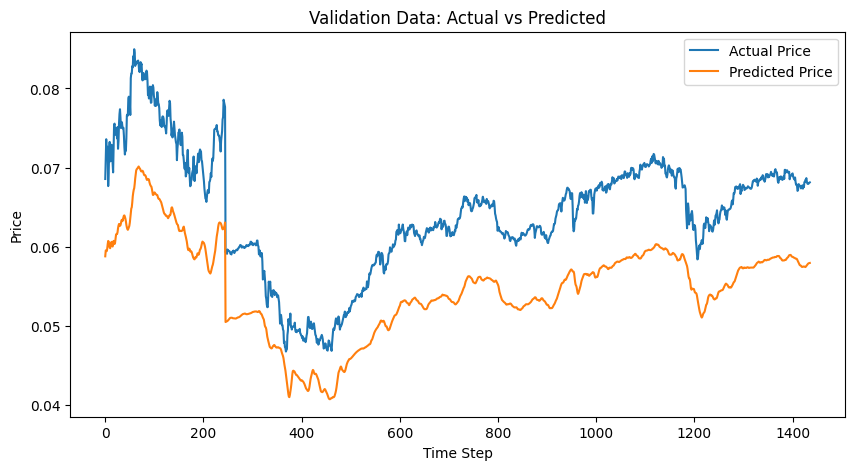

In [13]:
plt.figure(figsize=(10,5))

plt.plot(y_val, label='Actual Price')
plt.plot(y_val_pred, label='Predicted Price')

plt.title('Validation Data: Actual vs Predicted')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()

plt.show()

D) Revisit the previous steps to make at least three models in total by changing architecture and hyperparameters.

In [14]:
model_2 = Sequential([
    Reshape((look_back, 1), input_shape = (look_back, )),
    Conv1D(32, 3, activation = 'relu'),
    Dropout(0.3),
    SimpleRNN(64),
    Dense(1, activation = 'linear')
])
model_2.compile(loss = 'mean_squared_error', optimizer = 'adam')

In [ ]:
history = model_2.fit(X_train, y_train, epochs = 20, batch_size = 32)
print("Training loss: ", history.history['loss'][-1])

Epoch 1/3
351/351 [==============================] - 2s 4ms/step - loss: 0.0011
Epoch 2/3
351/351 [==============================] - 2s 5ms/step - loss: 4.6431e-04
Epoch 3/3
351/351 [==============================] - 2s 5ms/step - loss: 4.5459e-04
Training loss:  0.00045458920067176223


In [16]:
y_val_pred = model_2.predict(X_val)
print("Validation loss: ", mean_squared_error(y_val, y_val_pred))

45/45 [==============================] - 0s 3ms/step
Validation loss:  1.0489303407622064e-05


In [17]:
model_3 = Sequential([
    Reshape((look_back, 1), input_shape = (look_back, )),
    Conv1D(32, 3, activation = 'relu'),
    Dropout(0.3),
    SimpleRNN(64),
    Dense(16, activation = 'relu'),
    Dropout(0.2),
    Dense(1, activation = 'linear')
])
model_3.compile(loss = 'mean_squared_error', optimizer = 'adam')

In [ ]:
history = model_3.fit(X_train, y_train, epochs = 20, batch_size = 32)
print("Training loss: ", history.history['loss'][-1])

Epoch 1/3
351/351 [==============================] - 2s 4ms/step - loss: 0.0012
Epoch 2/3
351/351 [==============================] - 1s 4ms/step - loss: 9.3582e-04
Epoch 3/3
351/351 [==============================] - 2s 7ms/step - loss: 7.4647e-04
Training loss:  0.0007464696536771953


In [19]:
y_val_pred = model_3.predict(X_val)
print("Validation loss: ", mean_squared_error(y_val, y_val_pred))

45/45 [==============================] - 0s 4ms/step
Validation loss:  2.8755867363576e-05


E) Once you are finished altering hyperparameters, present neatly the training and validation loss along with the plots for each model showing predicted prices and actual prices. Choose the best model by comparing how each model did on training and validation data; provide your reasoning in markdown.

Model 1


Epoch 1/3
351/351 [==============================] - 1s 4ms/step - loss: 3.6273e-04
Epoch 2/3
351/351 [==============================] - 1s 4ms/step - loss: 3.3011e-04
Epoch 3/3
351/351 [==============================] - 1s 4ms/step - loss: 3.7399e-04
Training loss:  0.0003739941748790443
45/45 [==============================] - 0s 2ms/step
Validation loss:  1.3143188640872963e-05


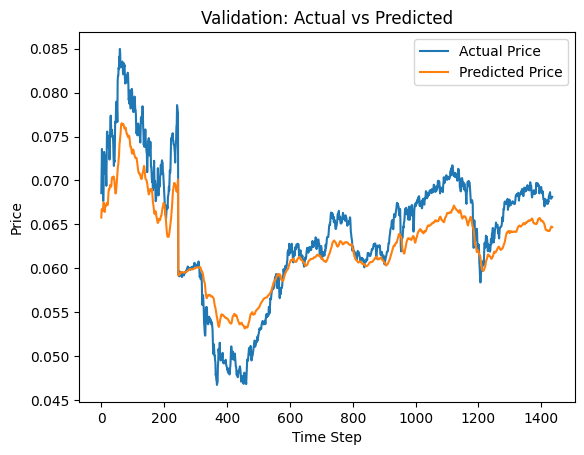



Model 2
Epoch 1/3
351/351 [==============================] - 2s 6ms/step - loss: 4.0284e-04
Epoch 2/3
351/351 [==============================] - 2s 5ms/step - loss: 3.6449e-04
Epoch 3/3
351/351 [==============================] - 2s 4ms/step - loss: 4.0120e-04
Training loss:  0.000401203113142401
45/45 [==============================] - 0s 2ms/step
Validation loss:  6.548166173529059e-05


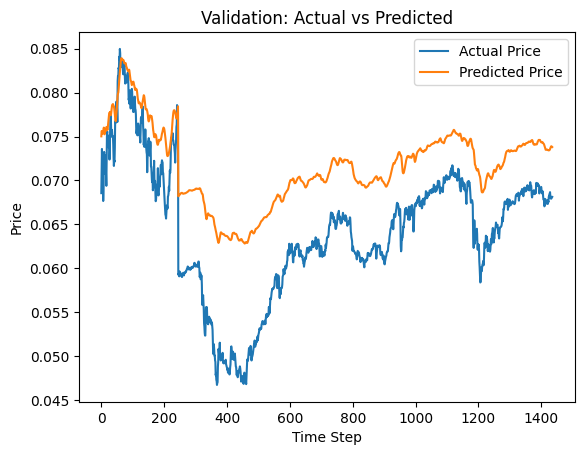



Model 3
Epoch 1/3
351/351 [==============================] - 2s 5ms/step - loss: 6.8314e-04
Epoch 2/3
351/351 [==============================] - 2s 5ms/step - loss: 7.2605e-04
Epoch 3/3
351/351 [==============================] - 1s 4ms/step - loss: 7.1225e-04
Training loss:  0.0007122545503079891
45/45 [==============================] - 0s 4ms/step
Validation loss:  5.117087906818517e-06


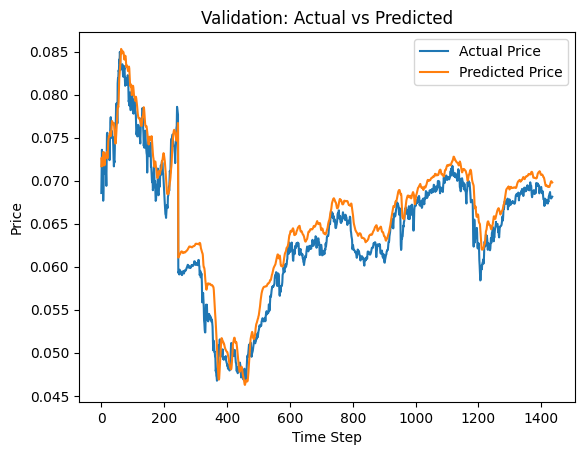

In [20]:
models = [model_1, model_2, model_3]
for i, model in (enumerate(models, start = 1)):
    print(f"Model {i}")
    model.compile(loss = 'mean_squared_error', optimizer = 'adam')
    model.fit(X_train, y_train, epochs = 3, batch_size = 32, verbose = 0)
    history = model.fit(X_train, y_train, epochs = 3, batch_size = 32)
    print("Training loss: ", history.history['loss'][-1])
    y_val_pred = model.predict(X_val)
    print("Validation loss: ", mean_squared_error(y_val, y_val_pred))
    plt.figure()
    plt.plot(y_val, label='Actual Price')
    plt.plot(y_val_pred, label='Predicted Price')
    plt.title('Validation: Actual vs Predicted')
    plt.xlabel('Time Step')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    print("\n")

Model 2 performed best with the lowest validation loss.

F) With the best model, make predictions on the testing data; calculate the testing loss and present a scatter plot of the predictions along with the true values. 

192/192 [==============================] - 1s 3ms/step
Testing loss:  0.0006077167749422999


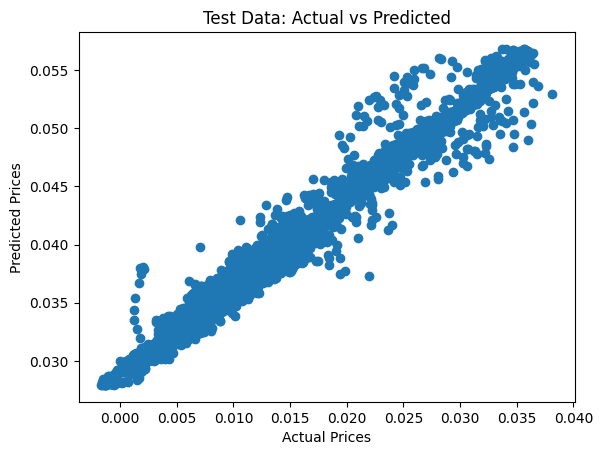

In [21]:
best_model = model_2
y_test_pred = model_2.predict(X_test)
test_loss = mean_squared_error(y_test, y_test_pred)
print("Testing loss: ", test_loss)

plt.figure()
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Test Data: Actual vs Predicted")
plt.show()

Ideally, this plot would be a straight line passing through the origin, indicating the X and Y values, the actual and predicted prices are the exact same. Currently our plot is showing slight differences between the two, corresponding to the loss on the miniscule scale of 10^-5.

### Discussion
A) Select the best model based on quantitative metrics and plots. Consider zooming-in on problem areas when comparing performance. Justify your selection using markdown.

Of the three models, Model 2 was the most consistent in terms of performance on both the training and validation sets, which led to it being the most justifiable choice for the best model. This is because Model 2 had the lowest training loss of 0.000301, which was the lowest of all the three models. This implies that the use of a larger filter bank, as seen in Conv1D(32), in combination with a larger SimpleRNN(64), which had a larger hidden state, was sufficient in representing the information embedded in the training sequences. Additionally, the model was able to do so without compromising on the validation loss, implying that the use of Dropout(0.3) was sufficient in preventing the model from overfitting, as it randomly drops some of the features in the model.

In [22]:
%matplotlib notebook

plt.figure()
plt.plot(y_test, label='Actual Price')
plt.plot(y_test_pred, label='Predicted Price')
plt.title('Testing: Actual vs Predicted')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

<IPython.core.display.Javascript object>

B) Use markdown to describe how well you feel your model would work to predict closing stock prices two days into the future. Give a quantitative estimate of the error in the predictions.

The validation and test results indicate that Model 2 is capable of capturing the overall directional trends of the closing price movements of stocks over two days with a certain level of accuracy, as indicated by the close similarity between the actual and predicted closing prices in the validation plot. The extremely low validation losses of all models, which are in the range of 1e-05 or lower in the scaled domain, indicate that MinMaxScaler normalisation compresses losses significantly. It would be expected that the actual prediction error in USD terms will be larger in proportion once predictions are reversed back to the original space. It is important to take this into consideration when trying to view and understand the model, as it is possible to get an overly optimistic view of prediction accuracy without contextualizing it with the original price scales of the target stocks.